In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [4]:
df = pd.read_csv("robot_6dof_dataset_100000.csv")

print(df.head())
print(df.shape)


          x         y         z        qx        qy        qz        qw  \
0 -2.329131  0.901417  0.632726  0.304408 -0.811965  0.120671  0.483206   
1 -0.998224 -2.309097  0.706872 -0.176640 -0.021707 -0.743786  0.644290   
2 -3.080353  1.222846 -0.602774  0.377714  0.897657 -0.158633  0.162419   
3  1.331950  1.163471 -1.633395 -0.846923  0.122721  0.317182  0.408725   
4 -2.329253  0.739324  1.388622  0.243079  0.362487 -0.899188  0.031263   

           j1         j2          j3         j4         j5          j6  
0  177.277312  40.556323   -7.759785 -83.735354  60.892159  -15.149913  
1 -153.118978 -16.559584  -87.209377  27.210316  12.167601 -164.417519  
2  174.260438   4.588009   -2.062385  39.317751 -20.070234   14.442166  
3   58.129930  94.815914 -115.326219  23.616632 -18.430521 -130.522326  
4 -131.626688  28.456916  -51.113771  49.149088 -74.394015  112.140091  
(100000, 13)


In [5]:
BASE_HEIGHT = 0.25
UPPER_ARM_LENGTH = 1.2
FOREARM_LENGTH = 1.0
WRIST_LENGTH = 0.45
TOOL_LENGTH = 0.35
TCP_OFFSET = 0.5


In [6]:
pose_X = df[["x", "y", "z", "qx", "qy", "qz", "qw"]].values
angles_deg = df[["j1", "j2", "j3", "j4", "j5", "j6"]].values

np.random.seed(42)

noise = np.random.normal(loc=0.0, scale=40.0, size=angles_deg.shape)
seed_angles_deg = angles_deg + noise

joint_mins = np.array([-180, -20, -120, -90, -90, -180])
joint_maxs = np.array([180, 140, 0, 90, 90, 180])

seed_angles_deg = np.clip(seed_angles_deg, joint_mins, joint_maxs)

X = np.concatenate([pose_X, seed_angles_deg], axis=1)

angles_rad = np.deg2rad(angles_deg)

y = np.concatenate([np.sin(angles_rad), np.cos(angles_rad)], axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (100000, 13)
y shape: (100000, 12)


In [7]:
X_train, X_temp, y_train, y_temp, angles_train, angles_temp = train_test_split(
    X, y, angles_deg, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test, angles_val, angles_test = train_test_split(
    X_temp, y_temp, angles_temp, test_size=0.50, random_state=42
)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))


Train: 70000
Val: 15000
Test: 15000


In [8]:
x_scaler = StandardScaler()

X_train_s = x_scaler.fit_transform(X_train)
X_val_s = x_scaler.transform(X_val)
X_test_s = x_scaler.transform(X_test)


In [9]:
def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32).to(device)


X_train_t = to_tensor(X_train_s)
y_train_t = to_tensor(y_train)

X_val_t = to_tensor(X_val_s)
y_val_t = to_tensor(y_val)

X_test_t = to_tensor(X_test_s)
y_test_t = to_tensor(y_test)

target_pose_train_t = to_tensor(X_train[:, :7])
target_pose_val_t = to_tensor(X_val[:, :7])
target_pose_test_t = to_tensor(X_test[:, :7])


In [10]:
batch_size = 256

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t, target_pose_train_t),
    batch_size=batch_size,
    shuffle=True,
)


In [11]:
def sincos_to_angles_deg_np(y_pred):
    sin_vals = y_pred[:, :6]
    cos_vals = y_pred[:, 6:]

    angles_rad = np.arctan2(sin_vals, cos_vals)
    return np.rad2deg(angles_rad)


def angular_error_deg(pred, true):
    return np.abs((pred - true + 180) % 360 - 180)


In [12]:
def make_transform(batch_size):
    T = torch.eye(4, device=device).unsqueeze(0).repeat(batch_size, 1, 1)
    return T


def trans_torch(x, y, z, batch_size):
    T = make_transform(batch_size)
    T[:, 0, 3] = x
    T[:, 1, 3] = y
    T[:, 2, 3] = z
    return T


def rot_x_torch(a):
    batch_size = a.shape[0]
    T = make_transform(batch_size)

    c = torch.cos(a)
    s = torch.sin(a)

    T[:, 1, 1] = c
    T[:, 1, 2] = -s
    T[:, 2, 1] = s
    T[:, 2, 2] = c

    return T


def rot_y_torch(a):
    batch_size = a.shape[0]
    T = make_transform(batch_size)

    c = torch.cos(a)
    s = torch.sin(a)

    T[:, 0, 0] = c
    T[:, 0, 2] = s
    T[:, 2, 0] = -s
    T[:, 2, 2] = c

    return T


def rot_z_torch(a):
    batch_size = a.shape[0]
    T = make_transform(batch_size)

    c = torch.cos(a)
    s = torch.sin(a)

    T[:, 0, 0] = c
    T[:, 0, 1] = -s
    T[:, 1, 0] = s
    T[:, 1, 1] = c

    return T


In [13]:
def sincos_to_angles_rad_torch(pred_sincos):
    sin_vals = pred_sincos[:, :6]
    cos_vals = pred_sincos[:, 6:]

    return torch.atan2(sin_vals, cos_vals)


def fk_torch_from_sincos(pred_sincos):
    angles = sincos_to_angles_rad_torch(pred_sincos)

    j1 = angles[:, 0]
    j2 = angles[:, 1]
    j3 = angles[:, 2]
    j4 = angles[:, 3]
    j5 = angles[:, 4]
    j6 = angles[:, 5]

    batch_size = pred_sincos.shape[0]

    T = make_transform(batch_size)

    T = T @ trans_torch(
        torch.zeros(batch_size, device=device),
        torch.full((batch_size,), BASE_HEIGHT, device=device),
        torch.zeros(batch_size, device=device),
        batch_size,
    )

    T = T @ rot_y_torch(j1)
    T = T @ rot_z_torch(j2)

    T = T @ trans_torch(
        torch.full((batch_size,), UPPER_ARM_LENGTH, device=device),
        torch.zeros(batch_size, device=device),
        torch.zeros(batch_size, device=device),
        batch_size,
    )

    T = T @ rot_z_torch(j3)

    T = T @ trans_torch(
        torch.full((batch_size,), FOREARM_LENGTH, device=device),
        torch.zeros(batch_size, device=device),
        torch.zeros(batch_size, device=device),
        batch_size,
    )

    T = T @ rot_z_torch(j4)

    T = T @ trans_torch(
        torch.full((batch_size,), WRIST_LENGTH, device=device),
        torch.zeros(batch_size, device=device),
        torch.zeros(batch_size, device=device),
        batch_size,
    )

    T = T @ rot_y_torch(j5)

    T = T @ trans_torch(
        torch.full((batch_size,), TOOL_LENGTH, device=device),
        torch.zeros(batch_size, device=device),
        torch.zeros(batch_size, device=device),
        batch_size,
    )

    T = T @ rot_x_torch(j6)

    T = T @ trans_torch(
        torch.full((batch_size,), TCP_OFFSET, device=device),
        torch.zeros(batch_size, device=device),
        torch.zeros(batch_size, device=device),
        batch_size,
    )

    position = T[:, :3, 3]
    rotation = T[:, :3, :3]

    return position, rotation


In [14]:
def rotation_matrix_to_quaternion_torch(R):
    batch_size = R.shape[0]

    qw = torch.sqrt(torch.clamp(1 + R[:, 0, 0] + R[:, 1, 1] + R[:, 2, 2], min=1e-8)) / 2
    qx = (R[:, 2, 1] - R[:, 1, 2]) / (4 * qw + 1e-8)
    qy = (R[:, 0, 2] - R[:, 2, 0]) / (4 * qw + 1e-8)
    qz = (R[:, 1, 0] - R[:, 0, 1]) / (4 * qw + 1e-8)

    q = torch.stack([qx, qy, qz, qw], dim=1)

    sign = torch.where(q[:, 3:4] < 0, -1.0, 1.0)
    q = q * sign

    q = q / (torch.norm(q, dim=1, keepdim=True) + 1e-8)

    return q


In [15]:
class IKNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(13, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
        )

    def forward(self, x):
        return self.net(x)


In [16]:
def ik_loss(pred_sincos, true_sincos, target_pose):
    target_position = target_pose[:, :3]
    target_quaternion = target_pose[:, 3:7]

    pred_position, pred_rotation = fk_torch_from_sincos(pred_sincos)
    pred_quaternion = rotation_matrix_to_quaternion_torch(pred_rotation)

    angle_loss = nn.functional.mse_loss(pred_sincos, true_sincos)

    position_loss = nn.functional.mse_loss(pred_position, target_position)

    quat_dot = torch.abs(torch.sum(pred_quaternion * target_quaternion, dim=1))
    quat_dot = torch.clamp(quat_dot, -1.0, 1.0)
    orientation_loss = torch.mean(1.0 - quat_dot)

    total_loss = angle_loss + 20.0 * position_loss + 2.0 * orientation_loss

    return total_loss, angle_loss, position_loss, orientation_loss


In [18]:
model = IKNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=8, factor=0.5
)

epochs = 250
patience = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")
patience_counter = 0

for epoch in range(epochs):
    model.train()

    batch_total_losses = []

    for xb, yb, target_pose_b in train_loader:
        optimizer.zero_grad()

        preds = model(xb)

        total_loss, angle_loss, position_loss, orientation_loss = ik_loss(
            preds, yb, target_pose_b
        )

        total_loss.backward()
        optimizer.step()

        batch_total_losses.append(total_loss.item())

    train_loss = np.mean(batch_total_losses)

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)

        val_total_loss, val_angle_loss, val_position_loss, val_orientation_loss = (
            ik_loss(val_preds, y_val_t, target_pose_val_t)
        )

    val_loss = val_total_loss.item()
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_fk_loss_ik_model.pth")
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train: {train_loss:.6f} | "
            f"Val: {val_loss:.6f} | "
            f"Val Angle: {val_angle_loss.item():.6f} | "
            f"Val Pos: {val_position_loss.item():.6f} | "
            f"Val Ori: {val_orientation_loss.item():.6f}"
        )

    if patience_counter >= patience:
        print("Early stopping")
        break

print("Best validation loss:", best_val_loss)


Epoch 000 | Train: 5.982817 | Val: 2.119761 | Val Angle: 0.710438 | Val Pos: 0.046320 | Val Ori: 0.241456
Epoch 010 | Train: 1.425704 | Val: 0.862504 | Val Angle: 0.524643 | Val Pos: 0.006581 | Val Ori: 0.103116
Epoch 020 | Train: 1.383848 | Val: 0.852522 | Val Angle: 0.508199 | Val Pos: 0.006567 | Val Ori: 0.106493
Epoch 030 | Train: 1.093457 | Val: 0.737896 | Val Angle: 0.471583 | Val Pos: 0.005329 | Val Ori: 0.079862
Epoch 040 | Train: 1.147548 | Val: 0.744161 | Val Angle: 0.479892 | Val Pos: 0.004768 | Val Ori: 0.084457
Epoch 050 | Train: 1.053317 | Val: 0.697844 | Val Angle: 0.465153 | Val Pos: 0.003571 | Val Ori: 0.080632
Epoch 060 | Train: 0.996940 | Val: 0.693197 | Val Angle: 0.455525 | Val Pos: 0.004025 | Val Ori: 0.078584
Epoch 070 | Train: 1.002990 | Val: 0.678733 | Val Angle: 0.460308 | Val Pos: 0.002847 | Val Ori: 0.080743
Epoch 080 | Train: 0.988650 | Val: 0.680112 | Val Angle: 0.456912 | Val Pos: 0.003113 | Val Ori: 0.080471
Epoch 090 | Train: 0.926095 | Val: 0.646168 | 

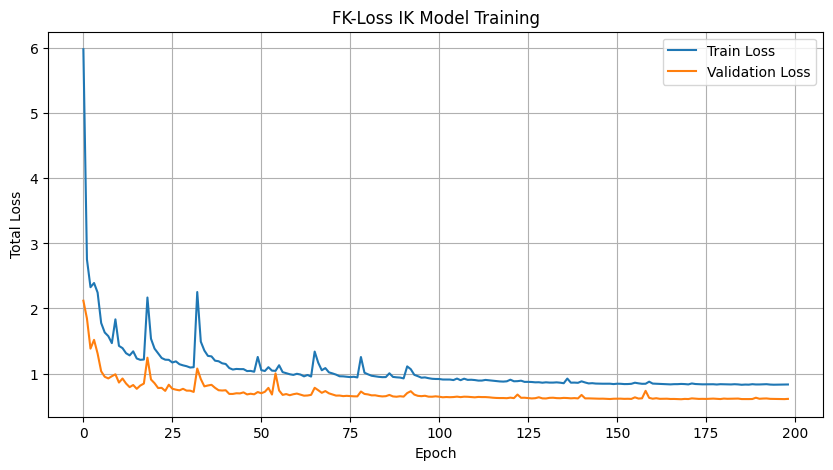

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("FK-Loss IK Model Training")
plt.legend()
plt.grid(True)
plt.show()


In [20]:
model.load_state_dict(torch.load("best_fk_loss_ik_model.pth", map_location=device))
model.eval()

with torch.no_grad():
    pred_test_sincos = model(X_test_t)

pred_sincos_np = pred_test_sincos.cpu().numpy()
pred_angles = sincos_to_angles_deg_np(pred_sincos_np)

angle_errors = angular_error_deg(pred_angles, angles_test)

for i in range(6):
    print(f"Joint {i + 1} MAE: {angle_errors[:, i].mean():.3f} degrees")
    print(f"Joint {i + 1} Max Error: {angle_errors[:, i].max():.3f} degrees")
    print()

print("Overall MAE:", angle_errors.mean())


Joint 1 MAE: 141.271 degrees
Joint 1 Max Error: 179.992 degrees

Joint 2 MAE: 73.513 degrees
Joint 2 Max Error: 179.997 degrees

Joint 3 MAE: 106.379 degrees
Joint 3 Max Error: 179.999 degrees

Joint 4 MAE: 40.456 degrees
Joint 4 Max Error: 164.268 degrees

Joint 5 MAE: 45.370 degrees
Joint 5 Max Error: 102.367 degrees

Joint 6 MAE: 135.079 degrees
Joint 6 Max Error: 180.000 degrees

Overall MAE: 90.34467796274816


C:\Users\shivo\AppData\Local\Temp\ipykernel_5968\2969084404.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_fk_loss_ik_model.pth",

In [21]:
with torch.no_grad():
    pred_position_t, pred_rotation_t = fk_torch_from_sincos(pred_test_sincos)
    pred_quaternion_t = rotation_matrix_to_quaternion_torch(pred_rotation_t)

target_position_t = target_pose_test_t[:, :3]
target_quaternion_t = target_pose_test_t[:, 3:7]

position_errors = torch.norm(pred_position_t - target_position_t, dim=1).cpu().numpy()

quat_dot = torch.abs(torch.sum(pred_quaternion_t * target_quaternion_t, dim=1))
quat_dot = torch.clamp(quat_dot, -1.0, 1.0)

orientation_errors_rad = (2 * torch.acos(quat_dot)).cpu().numpy()

print("FK Position Error")
print("Mean:", position_errors.mean())
print("Median:", np.median(position_errors))
print("Max:", position_errors.max())

print("\nFK Orientation Error")
print("Mean radians:", orientation_errors_rad.mean())
print("Median radians:", np.median(orientation_errors_rad))
print("Mean degrees:", np.rad2deg(orientation_errors_rad.mean()))
print("Median degrees:", np.rad2deg(np.median(orientation_errors_rad)))
print("Max degrees:", np.rad2deg(orientation_errors_rad.max()))


FK Position Error
Mean: 0.049735416
Median: 0.046053186
Max: 0.24207486

FK Orientation Error
Mean radians: 0.71916264
Median radians: 0.72432625
Mean degrees: 41.204983
Median degrees: 41.500835
Max degrees: 157.07936


In [22]:
sample_index = 0

sample_input = X_test[sample_index]
sample_pose = sample_input[:7]
sample_seed = sample_input[7:]

true_angles = angles_test[sample_index]

model_input_scaled = x_scaler.transform(sample_input.reshape(1, -1))
model_input_t = torch.tensor(model_input_scaled, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    pred_sincos = model(model_input_t)
    pred_position, pred_rotation = fk_torch_from_sincos(pred_sincos)
    pred_quaternion = rotation_matrix_to_quaternion_torch(pred_rotation)

pred_angles_sample = sincos_to_angles_deg_np(pred_sincos.cpu().numpy())[0]

print("Target pose:")
print(sample_pose)

print("\nSeed angles:")
print(sample_seed)

print("\nTrue angles:")
print(true_angles)

print("\nPredicted angles:")
print(pred_angles_sample)

print("\nCircular angle error:")
print(
    angular_error_deg(pred_angles_sample.reshape(1, -1), true_angles.reshape(1, -1))[0]
)

print("\nPredicted FK position:")
print(pred_position.cpu().numpy()[0])

print("\nPosition error:")
print(np.linalg.norm(pred_position.cpu().numpy()[0] - sample_pose[:3]))

target_q = sample_pose[3:7]
pred_q = pred_quaternion.cpu().numpy()[0]

dot = np.abs(np.dot(pred_q, target_q))
dot = np.clip(dot, -1.0, 1.0)

print("\nOrientation error degrees:")
print(np.rad2deg(2 * np.arccos(dot)))


Target pose:
[ 0.85728461  2.73000538 -0.07349839  0.90441709  0.19578697 -0.08298013
  0.36988038]

Seed angles:
[170.67474931  70.53181761 -12.87542153  83.45818818 -59.37218443
 -19.65578128]

True angles:
[115.40461253 121.57598574 -68.98156081  60.32714525 -71.46648949
  18.76684913]

Predicted angles:
[-174.45262      63.287354     35.847294     61.219547     -0.60261035
  -37.65604   ]

Circular angle error:
[ 70.14276601  58.28863222 104.82885466   0.89240202  70.86387914
  56.42288932]

Predicted FK position:
[ 0.8388021   2.7462947  -0.09044895]

Position error:
0.02990431314383698

Orientation error degrees:
12.772848341990736


In [23]:
torch.save(model.state_dict(), "robot_6dof_fk_loss_ik_nn.pth")
joblib.dump(x_scaler, "x_scaler_fk_loss_6dof.pkl")

print("Saved:")
print("robot_6dof_fk_loss_ik_nn.pth")
print("x_scaler_fk_loss_6dof.pkl")


Saved:
robot_6dof_fk_loss_ik_nn.pth
x_scaler_fk_loss_6dof.pkl
